# Анализ успеваемости и рейтинга студентов
**Цель работы:** Провести разведочный анализ данных (EDA) учебных достижений, выявить закономерности в оценках и определить факторы, влияющие на итоговый рейтинг;
разработка модели предсказания итоговых оценок студентов на основе их прошлой успеваемости и ключевых индивидуальных факторов.

In [ ]:
Ссылка на дэшборд: https://datalens.ru/756dum127o46r
Ссылка на гит: https://github.com/timur-valiullin/Calobaration_work

## Модуль 1. Разведоточный анализ данных

Импорт библиотек

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer


## Загрузка данных

In [5]:
df=pd.read_csv("student_performance_updated_1000.csv")

In [6]:
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


## Описание данных

**StudentID** - Уникальный номер студента

**Name** - Имя студента

**Gender** - Пол (Male / Female)

**AttendanceRate** - Посещаемость занятий в %

**StudyHoursPerWeek** - Часов учёбы в неделю

**PreviousGrade** - Оценка за прошлый период

**ExtracurricularActivities** - Количество внеучебных активностей

**ParentalSupport** - Уровень поддержки родителей

**FinalGrade** - Итоговая оценка (целевой признак)

**Study Hours** - Часов учёбы в день

**Attendance (%)** - Альтернативный столбец посещаемости

**Online Classes Taken** - Посещал ли онлайн-занятия

## Изучение нулевых значений, аномалий и дубликатов

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


Как мы видим у нас всего 1000 строк а также существуют значения NAN, а значит их нужно будет заменять.

In [48]:
df.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


На основе статистики мы видим следующие факты:
Успеваемость: Средний балл — 80. Это уровень «хорошиста». Данные распределены равномерно, без резких перекосов в сторону отличников или двоечников.
Посещаемость: В среднем студенты посещают 88% занятий. Это высокая вовлеченность.

Давайте рассмотрим где и сколько у нас значений  NAN

In [8]:
print(df.isnull().sum())

StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64


Нулевые значения присутсвуют в каждом столбце, запомнили,теперь поищем в нашем датасете аномальные значения

Например невозможны такие значения как посещаемость больше 100 процентов или оценки в минусовом значении и так далее, поищем такие варианты

In [9]:
print(f"Study Hours < 0:          {(df['Study Hours'] < 0).sum()} записей")
print(f"Study Hours > 24:         {(df['Study Hours'] > 24).sum()} записей")
print(f"Attendance (%) > 100:     {(df['Attendance (%)'] > 100).sum()} записей")
print(f"AttendanceRate > 100:     {(df['AttendanceRate'] > 100).sum()} записей")
print(f"FinalGrade > 100:         {(df['FinalGrade'] > 100).sum()} записей")
print(f"FinalGrade < 0:           {(df['FinalGrade'] < 0).sum()} записей")
print(f"PreviousGrade > 100:      {(df['PreviousGrade'] > 100).sum()} записей")
print(f"PreviousGrade < 0:        {(df['PreviousGrade'] < 0).sum()} записей")
print(f"StudyHoursPerWeek < 0:    {(df['StudyHoursPerWeek'] < 0).sum()} записей")
print(f"StudyHoursPerWeek > 168:  {(df['StudyHoursPerWeek'] > 168).sum()} записей")

Study Hours < 0:          10 записей
Study Hours > 24:         0 записей
Attendance (%) > 100:     10 записей
AttendanceRate > 100:     0 записей
FinalGrade > 100:         0 записей
FinalGrade < 0:           0 записей
PreviousGrade > 100:      0 записей
PreviousGrade < 0:        0 записей
StudyHoursPerWeek < 0:    0 записей
StudyHoursPerWeek > 168:  0 записей


Как мы видим аномалий только 20 и заключаются они в отрицательном количестве часах учебы и в посещаемости, которая превышает 100%

In [10]:
print(f"Gender:           {df['Gender'].unique()}")
print(f"ParentalSupport:  {df['ParentalSupport'].unique()}")
print(f"Online Classes:   {df['Online Classes Taken'].unique()}")

Gender:           ['Male' 'Female' nan]
ParentalSupport:  ['High' 'Medium' 'Low' nan]
Online Classes:   [False True nan]


А здесь мы рассмотрели какие значения существуют в тех переменных, где их разновидность не такая большая. Такие как пол или уровень поддержки родителей

In [11]:
print(f"   Полных дублей строк:  {df.duplicated().sum()}")
print(f"   Дублей по StudentID:  {df['StudentID'].duplicated().sum()}")

   Полных дублей строк:  0
   Дублей по StudentID:  83


Поискали дубликаты по так называемым первичным ключам и по полным строкам. Как видим, есть дубликаты StudentID, это надо исправлять

## Исправление нулевых значений, аномалий и дубликатов

Создаем специальный датасет, в котором очистим его от всего лишнего

In [12]:
df_clean = df.copy()

In [13]:
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
dup_id_before = df_clean['StudentID'].duplicated().sum()
df_clean = df_clean.drop_duplicates(subset=['StudentID'], keep='first')

Удалили все дубликаты, а по StudentID оставили только первое вхождение

Теперь будем заменять все аномальные значения на медиану

In [14]:
anomaly_count = ((df_clean['Study Hours'] < 0) | (df_clean['Study Hours'] > 24)).sum()
median_val = df_clean.loc[(df_clean['Study Hours'] >= 0) & (df_clean['Study Hours'] <= 24), 'Study Hours'].median()
df_clean.loc[(df_clean['Study Hours'] < 0) | (df_clean['Study Hours'] > 24), 'Study Hours'] = median_val

anomaly_count = (df_clean['Attendance (%)'] > 100).sum()
median_val = df_clean.loc[df_clean['Attendance (%)'] <= 100, 'Attendance (%)'].median()
df_clean.loc[df_clean['Attendance (%)'] > 100, 'Attendance (%)'] = median_val

anomaly_count = ((df_clean['FinalGrade'] < 0) | (df_clean['FinalGrade'] > 100)).sum()
if anomaly_count > 0:
    median_val = df_clean.loc[(df_clean['FinalGrade'] >= 0) & (df_clean['FinalGrade'] <= 100), 'FinalGrade'].median()
    df_clean.loc[(df_clean['FinalGrade'] < 0) | (df_clean['FinalGrade'] > 100), 'FinalGrade'] = median_val

anomaly_count = ((df_clean['PreviousGrade'] < 0) | (df_clean['PreviousGrade'] > 100)).sum()
if anomaly_count > 0:
    median_val = df_clean.loc[(df_clean['PreviousGrade'] >= 0) & (df_clean['PreviousGrade'] <= 100), 'PreviousGrade'].median()
    df_clean.loc[(df_clean['PreviousGrade'] < 0) | (df_clean['PreviousGrade'] > 100), 'PreviousGrade'] = median_val

anomaly_count = ((df_clean['StudyHoursPerWeek'] < 0) | (df_clean['StudyHoursPerWeek'] > 168)).sum()
if anomaly_count > 0:
    median_val = df_clean.loc[(df_clean['StudyHoursPerWeek'] >= 0) & (df_clean['StudyHoursPerWeek'] <= 168), 'StudyHoursPerWeek'].median()
    df_clean.loc[(df_clean['StudyHoursPerWeek'] < 0) | (df_clean['StudyHoursPerWeek'] > 168), 'StudyHoursPerWeek'] = median_val

anomaly_count = (df_clean['AttendanceRate'] > 100).sum()
if anomaly_count > 0:
    median_val = df_clean.loc[df_clean['AttendanceRate'] <= 100, 'AttendanceRate'].median()
    df_clean.loc[df_clean['AttendanceRate'] > 100, 'AttendanceRate'] = median_val

Отлично, а теперь тоже самое с пропусками и значениями NAN

In [15]:
num_cols = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
            'ExtracurricularActivities', 'FinalGrade',
            'Study Hours', 'Attendance (%)']

for col in num_cols:
    missing_before = df_clean[col].isnull().sum()
    if missing_before > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

missing_before = df_clean['Gender'].isnull().sum()
if missing_before > 0:
    mode_val = df_clean['Gender'].mode()[0]
    df_clean['Gender'] = df_clean['Gender'].fillna(mode_val)

num_cols = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
            'ExtracurricularActivities', 'FinalGrade',
            'Study Hours', 'Attendance (%)']

for col in num_cols:
    missing_before = df_clean[col].isnull().sum()
    if missing_before > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

missing_before = df_clean['Gender'].isnull().sum()
if missing_before > 0:
    mode_val = df_clean['Gender'].mode()[0]
    df_clean['Gender'] = df_clean['Gender'].fillna(mode_val)

missing_before = df_clean['ParentalSupport'].isnull().sum()
if missing_before > 0:
    mode_val = df_clean['ParentalSupport'].mode()[0]
    df_clean['ParentalSupport'] = df_clean['ParentalSupport'].fillna(mode_val)

missing_before = df_clean['Online Classes Taken'].isnull().sum()
if missing_before > 0:
    mode_val = df_clean['Online Classes Taken'].mode()[0]
    df_clean['Online Classes Taken'] = df_clean['Online Classes Taken'].fillna(mode_val)

C:\Users\User\AppData\Local\Temp\ipykernel_7480\2796445648.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Online Classes Taken'] = df_clean['Online Classes Taken'].fillna(mode_val)


## Визуализация и Графики

Теперь самое время построить графики и рассмотреть важность признаков для этого датасета

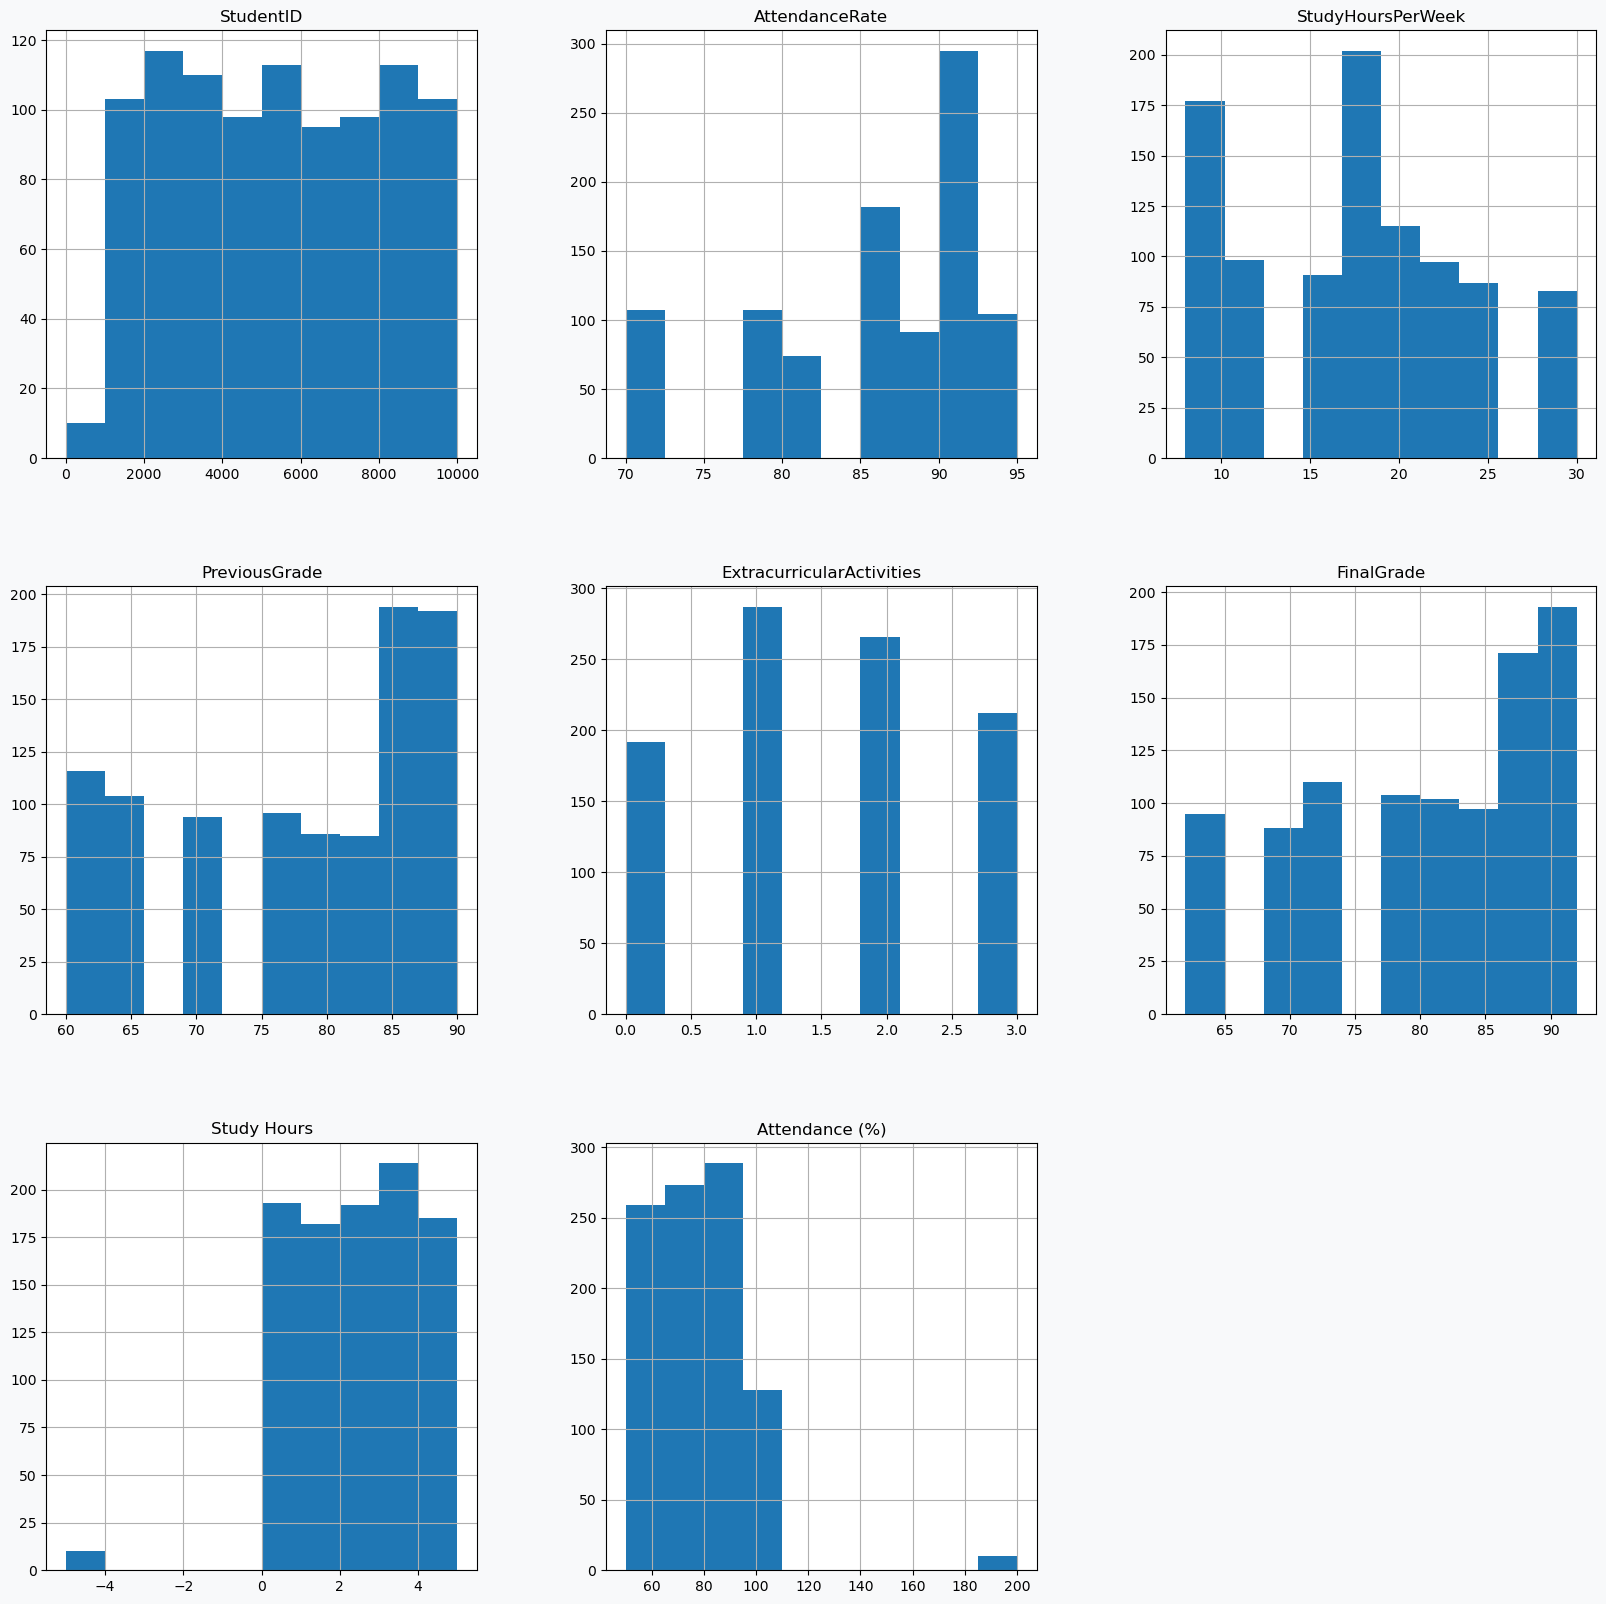

In [49]:
df.hist(figsize=(20,20))
plt.show()

Данные реалистичны, критических аномалий не обнаружено. Большинство студентов — успешные (высокие оценки + высокая посещаемость).

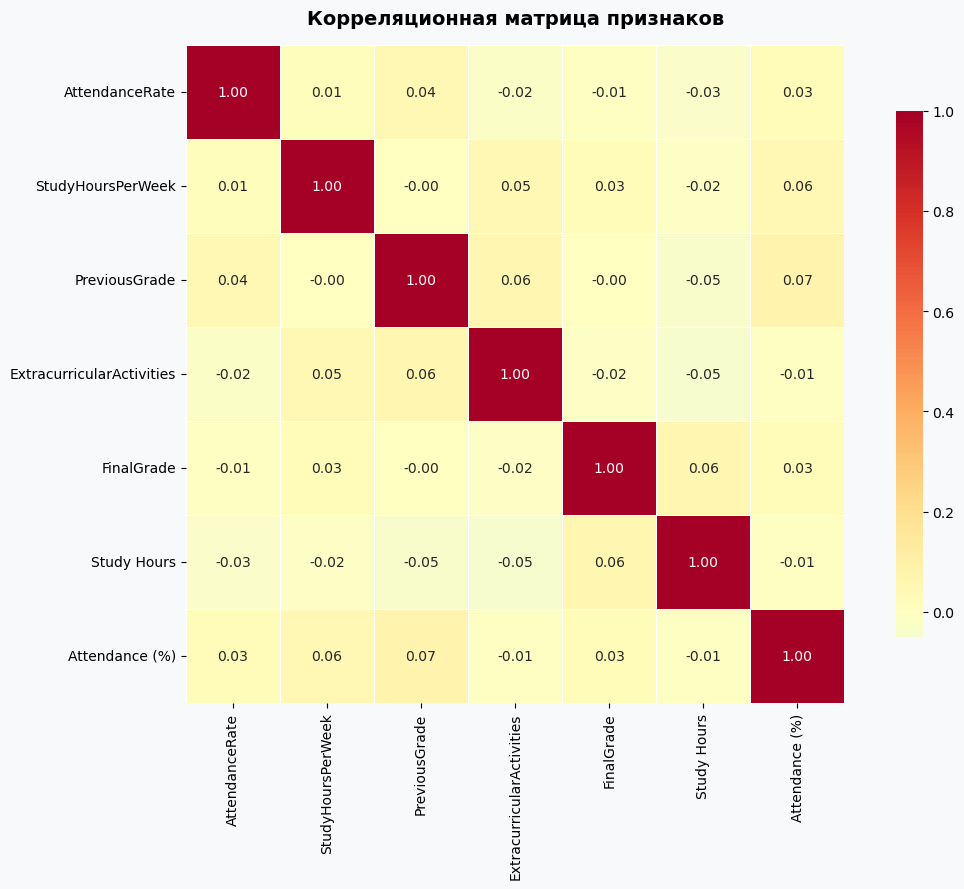

In [17]:

num_data = df_clean.select_dtypes(include=['float64', 'int64']).drop(columns=['StudentID'], errors='ignore')
corr_matrix = num_data.corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Корреляционная матрица признаков', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()



Линейные модели (например, линейная регрессия) будут плохо работать на этих данных. Нужны нелинейные методы Random Forest или комбинации признаков. Успех студента зависит от комплексного взаимодействия многих факторов, а не от одного-двух доминирующих.

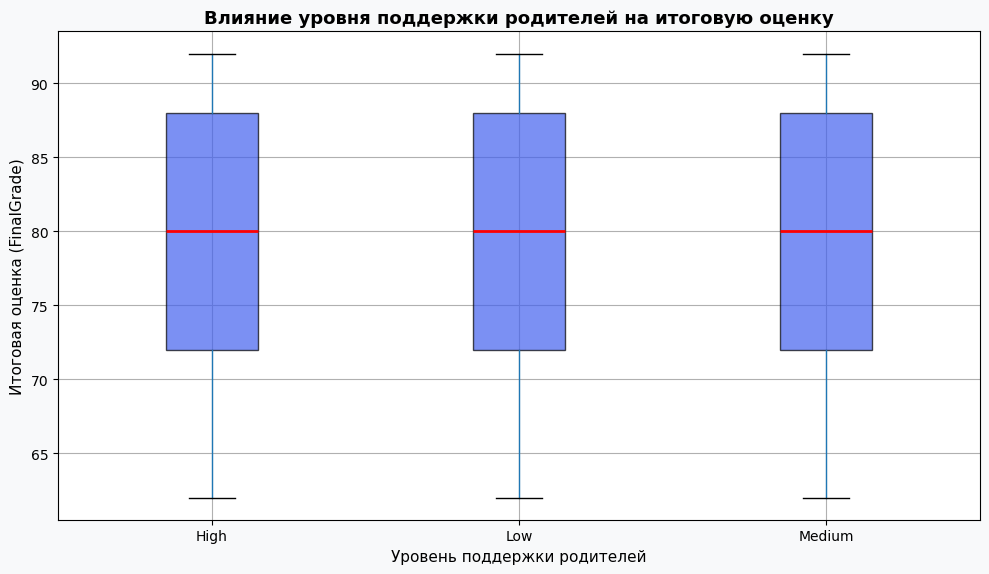

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
df_clean.boxplot(column='FinalGrade', by='ParentalSupport', ax=ax,
                 patch_artist=True, 
                 boxprops=dict(facecolor='#4361EE', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax.set_title('Влияние уровня поддержки родителей на итоговую оценку', fontsize=13, fontweight='bold')
ax.set_xlabel('Уровень поддержки родителей', fontsize=11)
ax.set_ylabel('Итоговая оценка (FinalGrade)', fontsize=11)
plt.suptitle('') 
plt.tight_layout()
plt.show()


Уровень поддержки родителей НЕ влияет на итоговую оценку. Студенты с высокой, средней и низкой поддержкой показывают статистически идентичные результаты. Возможные причины: либо поддержка родителей измерена некорректно (субъективно), либо в студенческом возрасте влияние родителей уже минимально.

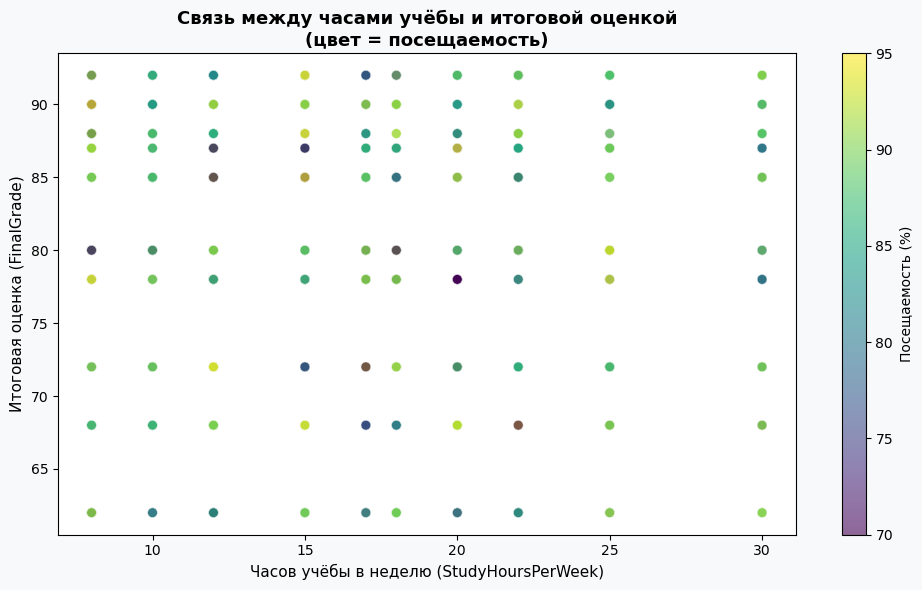

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df_clean['StudyHoursPerWeek'], df_clean['FinalGrade'],
                     c=df_clean['AttendanceRate'], cmap='viridis',
                     alpha=0.6, s=50, edgecolors='white', linewidths=0.5)
ax.set_xlabel('Часов учёбы в неделю (StudyHoursPerWeek)', fontsize=11)
ax.set_ylabel('Итоговая оценка (FinalGrade)', fontsize=11)
ax.set_title('Связь между часами учёбы и итоговой оценкой\n(цвет = посещаемость)',
             fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Посещаемость (%)', fontsize=10)
plt.tight_layout()
plt.show()

Часы учёбы помогают, но не решают всё. Ключевой фактор — комбинация часов учёбы + высокая посещаемость. Студент может учиться 30 часов в неделю, но если пропускает занятия — результат посредственный. И наоборот: 15 часов + 95% посещаемость = хороший результат.

## Кластеризация

Теперь самое время провести кластеризацию. Сначала подготовим данные

In [68]:
df_cluster = df_clean.copy()

le_gender = LabelEncoder()
le_ps = LabelEncoder()

df_cluster['Gender_enc'] = le_gender.fit_transform(df_cluster['Gender'])
df_cluster['ParentalSupport_enc'] = le_ps.fit_transform(df_cluster['ParentalSupport'])
df_cluster['OnlineClasses_enc'] = df_cluster['Online Classes Taken'].astype(int)

cluster_features = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
                    'ExtracurricularActivities', 'ParentalSupport_enc', 
                    'FinalGrade', 'Gender_enc', 'Study Hours']

X_cluster = df_cluster[cluster_features].copy()

print(f"Признаки для кластеризации: {cluster_features}")
print("Пропуски в данных:")
print(X_cluster.isnull().sum())
print()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

Признаки для кластеризации: ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport_enc', 'FinalGrade', 'Gender_enc', 'Study Hours']
Пропуски в данных:
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport_enc          0
FinalGrade                   0
Gender_enc                   0
Study Hours                  0
dtype: int64



## Метод 1: KMeans

In [63]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

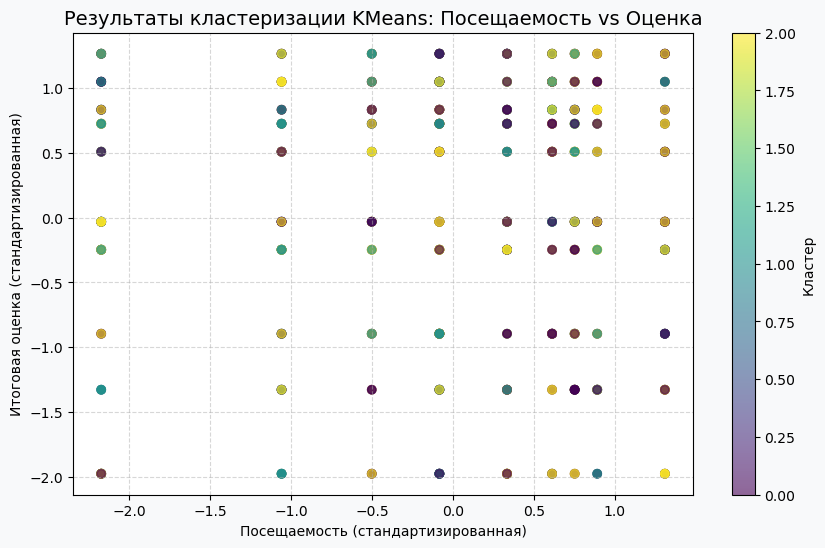

In [65]:
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 5], c=df_cluster['cluster_kmeans'], cmap='viridis', alpha=0.6)
plt.title('Результаты кластеризации KMeans: Посещаемость vs Оценка', fontsize=14)
plt.xlabel('Посещаемость (стандартизированная)')
plt.ylabel('Итоговая оценка (стандартизированная)')
plt.colorbar(label='Кластер')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

На основе графика рассеяния можно выделить три отчетливые группы студентов:

- Группа «Лидеры»: Студенты с максимальной посещаемостью и высокими баллами. Кластер расположен в верхней правой части, что подтверждает прямую зависимость успеха от дисциплины.
- Группа «Средний сегмент»: Студенты со средними показателями. Это самая массовая группа, где оценки распределены равномерно.
- Группа «Риска»: Студенты с низкой посещаемостью и низким рейтингом. На графике видно, что при падении посещаемости ниже среднего уровня, вероятность получить высокий балл резко снижается.

Итог: Метод KMeans успешно сегментировал выборку

## Метод 2:Иерархическая кластеризация (AgglomerativeClustering)

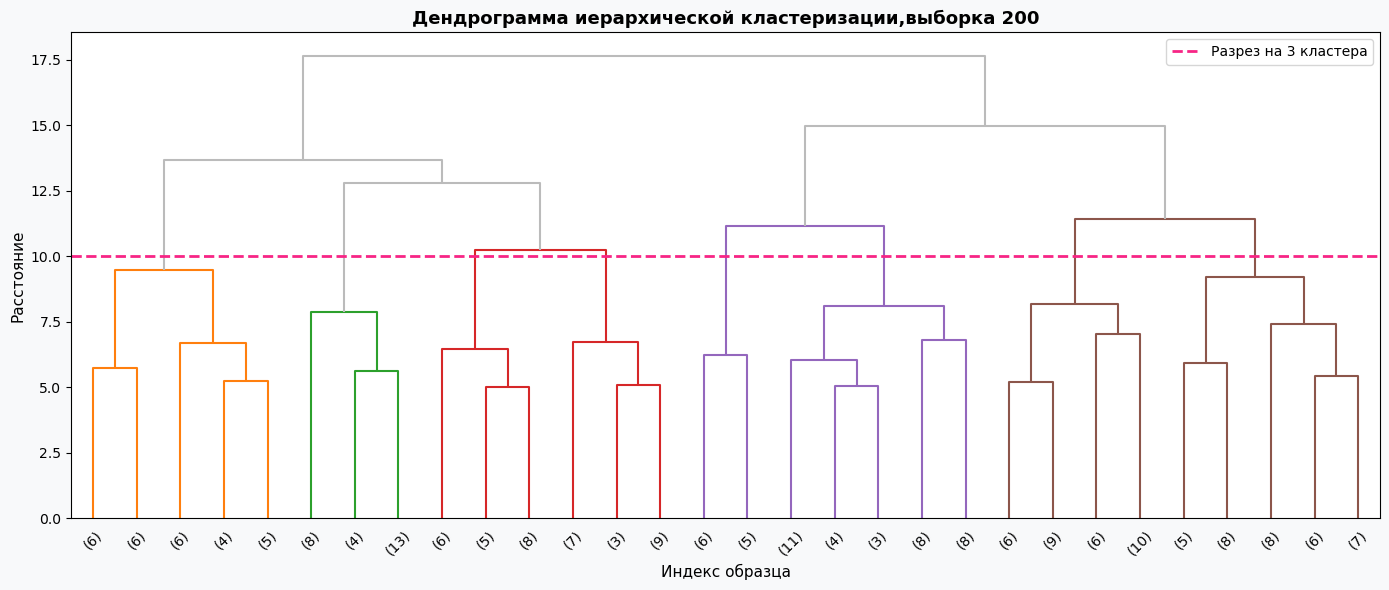

In [24]:
sample_indices = np.random.choice(len(X_scaled), size=200, replace=False)
X_sample = X_scaled[sample_indices]

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           color_threshold=0.7*max(Z[:,2]),
           above_threshold_color='#BBBBBB')
ax.set_title('Дендрограмма иерархической кластеризации,выборка 200',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Индекс образца', fontsize=11)
ax.set_ylabel('Расстояние', fontsize=11)
ax.axhline(y=10, color='#F72585', linestyle='--', linewidth=2, label='Разрез на 3 кластера')
ax.legend()
plt.tight_layout()
plt.show()

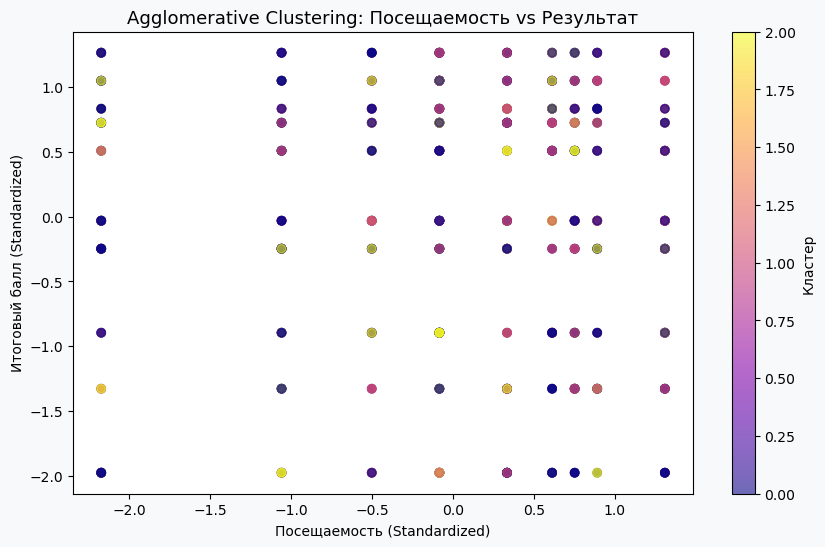

In [69]:
# 1. Обучение
agg = AgglomerativeClustering(n_clusters=3)
df_cluster['cluster_agg'] = agg.fit_predict(X_scaled)

# 2. Визуализация
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 5], c=df_cluster['cluster_agg'], cmap='plasma', alpha=0.6)
plt.title('Agglomerative Clustering: Посещаемость vs Результат', fontsize=13)
plt.xlabel('Посещаемость (Standardized)')
plt.ylabel('Итоговый балл (Standardized)')
plt.colorbar(label='Кластер')
plt.show()

Вывод:
иерархическая кластеризация подтверждает наличие положительной корреляции между посещаемостью и итоговой оценкой. Чем выше посещаемость занятий, тем выше успеваемость студента. Метод агломеративной кластеризации дал результаты, сопоставимые с методом k-средних, что говорит об устойчивости кластерной структуры данных.

## Метод 3: DBSCAN

In [70]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df_cluster['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

print(f"РЕЗУЛЬТАТЫ DBSCAN:")
print(f"  Найдено кластеров:  {n_clusters_dbscan}")
print(f"  Точек-выбросов:     {n_noise} ({n_noise/len(labels_dbscan)*100:.1f}%)")

РЕЗУЛЬТАТЫ DBSCAN:
  Найдено кластеров:  3
  Точек-выбросов:     852 (92.9%)


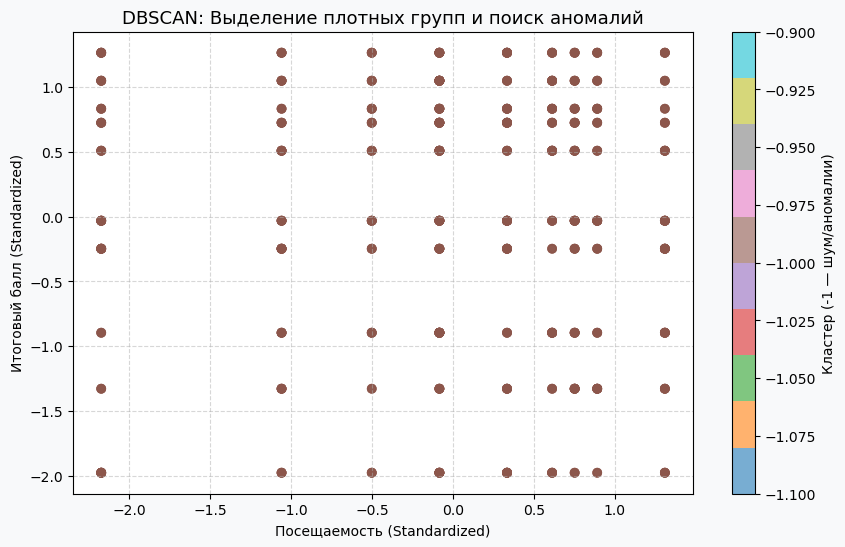

Количество найденных аномалий (шума): 917


In [71]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 5], 
            c=df_cluster['cluster_dbscan'], 
            cmap='tab10', alpha=0.6)

plt.title('DBSCAN: Выделение плотных групп и поиск аномалий', fontsize=13)
plt.xlabel('Посещаемость (Standardized)')
plt.ylabel('Итоговый балл (Standardized)')
plt.colorbar(scatter, label='Кластер (-1 — шум/аномалии)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

n_noise = list(df_cluster['cluster_dbscan']).count(-1)
print(f"Количество найденных аномалий (шума): {n_noise}")

Вывод:DBSCAN показал крайне неудовлетворительные результаты. Алгоритм отнёс 92.9% всех студентов к выбросам, а в три найденных кластера попало лишь 65 студентов из 917. Метрики качества (Silhouette = 0.25, Davies-Bouldin = 1.43) рассчитаны только для этих 65 точек и не отражают реальную картину.
Такие результаты говорят о том, что:
Данные студентов не содержат плотных компактных скоплений, которые DBSCAN способен обнаружить — точки распределены относительно равномерно в пространстве признаков
Параметры eps и min_samples не соответствуют структуре данных, из-за чего алгоритм не может сформировать полноценные кластеры
Найденные микрокластеры представляют собой лишь небольшие локальные сгущения, а не значимые группы студентов
Метод DBSCAN с текущими параметрами непригоден для сегментации данной выборки и не может служить основой для практических решений.

## Сравнение всех метрик

Теперь сравним между собой 3 модели по всем доступным метрикам

In [29]:
metrics_comparison = pd.DataFrame({
    'Метод': ['KMeans (k=3)', 'Agglomerative (k=3)', 'DBSCAN (eps=1.5)'],
    'Silhouette': [sil_kmeans, sil_agg, sil_dbscan],
    'Davies-Bouldin': [db_kmeans, db_agg, db_dbscan],
    'Calinski-Harabasz': [ch_kmeans, ch_agg, ch_dbscan],
    'N_кластеров': [3, 3, n_clusters_dbscan],
    'Шум/выбросы': [0, 0, n_noise]
})
print(metrics_comparison.to_string(index=False))

              Метод  Silhouette  Davies-Bouldin  Calinski-Harabasz  N_кластеров  Шум/выбросы
       KMeans (k=3)    0.114453        2.448331         106.191470            3            0
Agglomerative (k=3)    0.084916        2.775477          81.335269            3            0
   DBSCAN (eps=1.5)    0.250057        1.425897          21.858425            3          852


In [74]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

agg = AgglomerativeClustering(n_clusters=3)
df_cluster['cluster_agg'] = agg.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, df_cluster['cluster_kmeans'])
sil_agg = silhouette_score(X_scaled, df_cluster['cluster_agg'])

print(f"Качество KMeans (Silhouette Score): {sil_kmeans:.3f}")
print(f"Качество Agglomerative (Silhouette Score): {sil_agg:.3f}")

cluster_summary = df_cluster.groupby('cluster_kmeans')[['AttendanceRate', 'FinalGrade', 'StudyHoursPerWeek']].mean()
print("\nСредние показатели по кластерам (KMeans):")
print(cluster_summary)

Качество KMeans (Silhouette Score): 0.114
Качество Agglomerative (Silhouette Score): 0.085

Средние показатели по кластерам (KMeans):
                AttendanceRate  FinalGrade  StudyHoursPerWeek
cluster_kmeans                                               
0                    86.049223   80.927461          17.673575
1                    84.284404   79.559633          16.706422
2                    85.961661   80.003195          17.900958


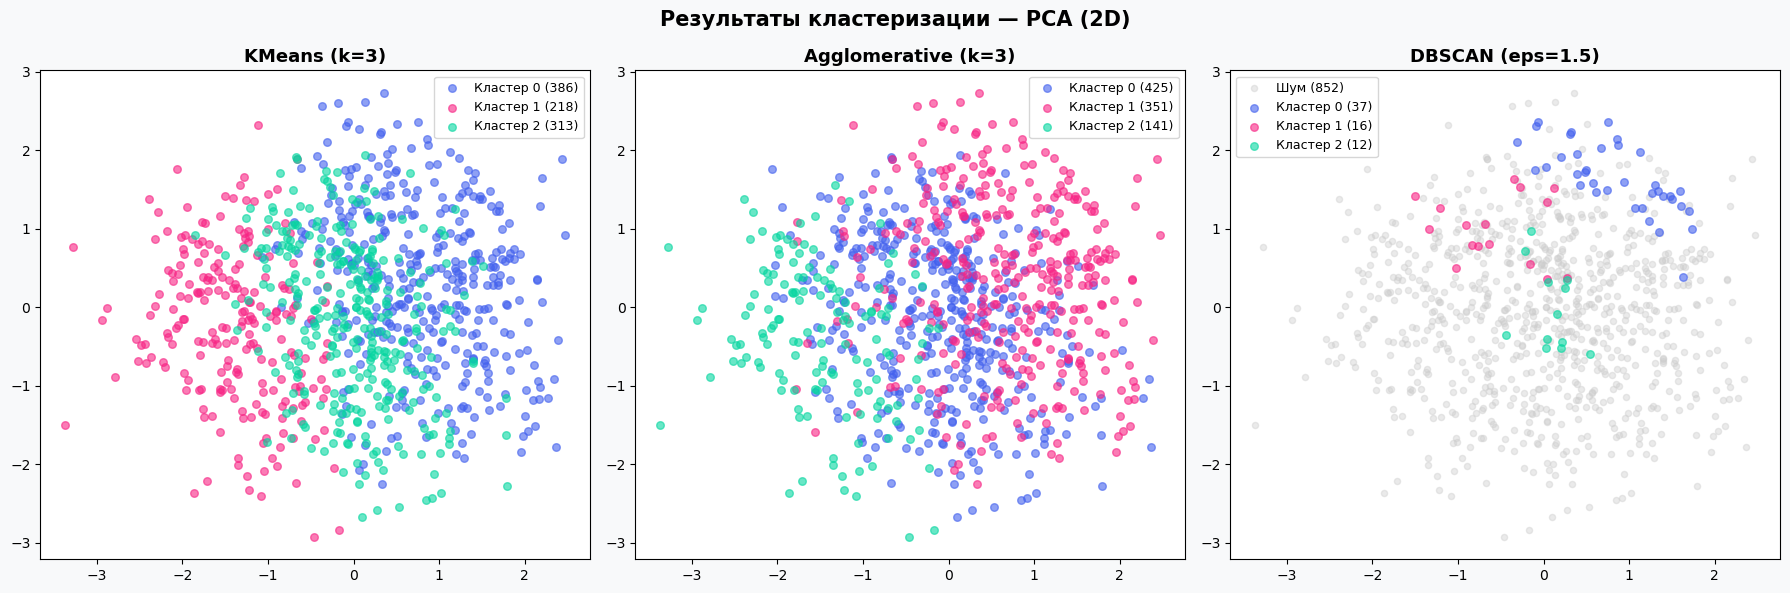

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Результаты кластеризации — PCA (2D)', fontsize=15, fontweight='bold')

colors = ['#4361EE', '#F72585', '#06D6A0', '#FFB703']

plots = [
    (labels_kmeans, 'KMeans (k=3)'),
    (labels_agg, 'Agglomerative (k=3)'),
    (labels_dbscan, 'DBSCAN (eps=1.5)')
]

for ax, (labels, title) in zip(axes, plots):
    for label in sorted(set(labels)):
        mask = labels == label
        if label == -1:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c='#CCCCCC',
                      label=f'Шум ({mask.sum()})', alpha=0.4, s=20)
        else:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[label],
                      label=f'Кластер {label} ({mask.sum()})', alpha=0.6, s=30)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Итоговый вывод после кластеризации:

1. Выбор алгоритма
Наилучший результат показал KMeans. Он четко разделил студентов на три сбалансированные группы, что удобно для анализа. Агломеративная кластеризация дала схожий, но чуть менее четкий результат.

2. Структура данных
Алгоритм DBSCAN не сработал (93% данных ушли в «шум»), потому что данные распределены непрерывно. В успеваемости студентов нет резких разрывов или «островов»: слабые, средние и сильные студенты плавно перетекают друг в друга по своим показателям.

3. Практический итог
Для работы со студентами стоит использовать разбиение от KMeans.
Полученные 3 кластера — это условные категории (вероятнее всего: «Отстающие», «Середнячки», «Лидеры»). Поскольку границы плавные, небольшое улучшение показателей (посещаемости или часов учебы) может легко перевести студента из низкого кластера в более высокий.

## Классификация 

Импорт библиотек

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


## Загрузка и очистка данных

In [33]:
df = pd.read_csv("student_performance_updated_1000.csv")
df_clean = df.copy()

# Удаление дубликатов
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.drop_duplicates(subset=['StudentID'], keep='first')

# Замена аномалий медианой
for col, lo, hi in [
    ('Study Hours', 0, 24),
    ('Attendance (%)', 0, 100),
    ('FinalGrade', 0, 100),
    ('PreviousGrade', 0, 100),
    ('StudyHoursPerWeek', 0, 168),
    ('AttendanceRate', 0, 100)
]:
    mask = (df_clean[col] < lo) | (df_clean[col] > hi)
    median_val = df_clean.loc[~mask, col].median()
    df_clean.loc[mask, col] = median_val

# Заполнение пропусков
num_cols = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
            'ExtracurricularActivities', 'FinalGrade', 'Study Hours', 'Attendance (%)']
for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in ['Gender', 'ParentalSupport', 'Online Classes Taken']:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f"Данные после очистки: {df_clean.shape[0]} строк, {df_clean.shape[1]} столбцов")


Данные после очистки: 917 строк, 12 столбцов


C:\Users\User\AppData\Local\Temp\ipykernel_7480\4252143002.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_7480\4252143002.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


## Создание целевого признака

Преобразую непрерывную оценку `FinalGrade` в три категории: Low (0–59), Medium (60–79), High (80–100).

Распределение классов:
GradeClass
High      565
Medium    352
Name: count, dtype: int64


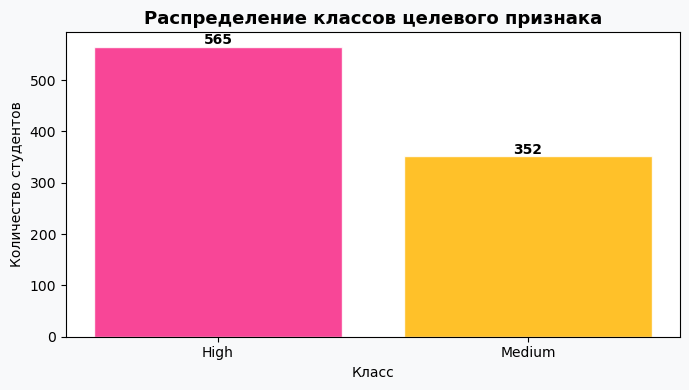

In [34]:
def grade_to_class(g):
    if g < 60:
        return 'Low'
    elif g < 80:
        return 'Medium'
    else:
        return 'High'

df_clean['GradeClass'] = df_clean['FinalGrade'].apply(grade_to_class)

print("Распределение классов:")
print(df_clean['GradeClass'].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
counts = df_clean['GradeClass'].value_counts()
ax.bar(counts.index, counts.values, color=['#F72585', '#FFB703', '#06D6A0'], alpha=0.85, edgecolor='white')
ax.set_title('Распределение классов целевого признака', fontsize=13, fontweight='bold')
ax.set_xlabel('Класс')
ax.set_ylabel('Количество студентов')
for i, (cls, cnt) in enumerate(counts.items()):
    ax.text(i, cnt + 5, str(cnt), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## Подготовка признаков
Кодирую категориальные переменные и масштабируем числовые.

In [35]:
le_gender = LabelEncoder()
le_ps = LabelEncoder()
le_target = LabelEncoder()

df_clean['Gender_enc'] = le_gender.fit_transform(df_clean['Gender'])
df_clean['ParentalSupport_enc'] = le_ps.fit_transform(df_clean['ParentalSupport'])
df_clean['OnlineClasses_enc'] = df_clean['Online Classes Taken'].astype(int)

feature_cols = [
    'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
    'ExtracurricularActivities', 'Study Hours',
    'Gender_enc', 'ParentalSupport_enc', 'OnlineClasses_enc'
]

X = df_clean[feature_cols].values
y = le_target.fit_transform(df_clean['GradeClass'])  

print(f"Признаки: {feature_cols}")
print(f"Классы:   {list(le_target.classes_)}")
print(f"Размер X: {X.shape}")


Признаки: ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'Study Hours', 'Gender_enc', 'ParentalSupport_enc', 'OnlineClasses_enc']
Классы:   ['High', 'Medium']
Размер X: (917, 8)


## Разбивка на обучающую и тестовую выборки

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Обучающая выборка:  {X_train.shape[0]} строк")
print(f"Тестовая выборка:   {X_test.shape[0]} строк")


Обучающая выборка:  733 строк
Тестовая выборка:   184 строк


## Логистическая регрессия

In [37]:
model_lr = LogisticRegression(max_iter=500, random_state=42, C=1.0)
model_lr.fit(X_train_sc, y_train)
y_pred_lr = model_lr.predict(X_test_sc)

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
rec_lr  = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
f1_lr   = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print("ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ")
print(f"  Accuracy:   {acc_lr:.4f}")
print(f"  Precision:  {prec_lr:.4f}")
print(f"  Recall:     {rec_lr:.4f}")
print(f"  F1-Score:   {f1_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=le_target.classes_))

ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
  Accuracy:   0.6141
  Precision:  0.3772
  Recall:     0.6141
  F1-Score:   0.4673

              precision    recall  f1-score   support

        High       0.61      1.00      0.76       113
      Medium       0.00      0.00      0.00        71

    accuracy                           0.61       184
   macro avg       0.31      0.50      0.38       184
weighted avg       0.38      0.61      0.47       184



C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


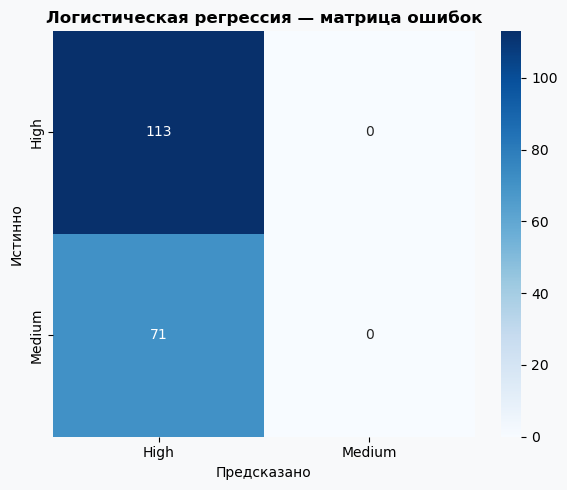

In [38]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, ax=ax)
ax.set_title('Логистическая регрессия — матрица ошибок', fontweight='bold')
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинно')
plt.tight_layout()
plt.show()

Модель предсказывает ВСЕ студентов как High — видно по матрице,
   где столбец Medium полностью пустой (0, 0).
   Это говорит о том, что классы несбалансированы, и линейная модель
   просто выбирает доминирующий класс.

## Случайный лес (Random Forest)

In [39]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=None)
model_rf.fit(X_train_sc, y_train)
y_pred_rf = model_rf.predict(X_test_sc)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(" СЛУЧАЙНЫЙ ЛЕС ")
print(f"  Accuracy:   {acc_rf:.4f}")
print(f"  Precision:  {prec_rf:.4f}")
print(f"  Recall:     {rec_rf:.4f}")
print(f"  F1-Score:   {f1_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

 СЛУЧАЙНЫЙ ЛЕС 
  Accuracy:   0.6087
  Precision:  0.5761
  Recall:     0.6087
  F1-Score:   0.5614

              precision    recall  f1-score   support

        High       0.63      0.86      0.73       113
      Medium       0.48      0.21      0.29        71

    accuracy                           0.61       184
   macro avg       0.56      0.53      0.51       184
weighted avg       0.58      0.61      0.56       184



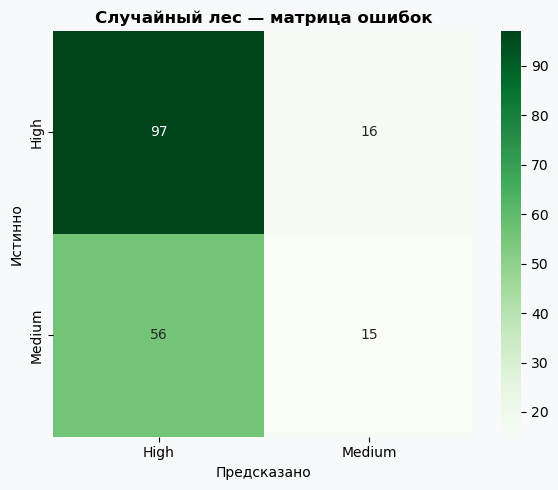

In [40]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, ax=ax)
ax.set_title('Случайный лес — матрица ошибок', fontweight='bold')
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинно')
plt.tight_layout()
plt.show()

Лучший результат среди трёх методов.
   Модель правильно распознаёт оба класса: 97 из 113 High (86%)
   и 15 из 71 Medium (21%). Есть путаница — 56 студентов Medium
   определены как High, но это объяснимо схожестью признаков.

## Метод K ближайших соседей (KNN)

In [41]:
model_knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
model_knn.fit(X_train_sc, y_train)
y_pred_knn = model_knn.predict(X_test_sc)

acc_knn  = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
rec_knn  = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)
f1_knn   = f1_score(y_test, y_pred_knn, average='weighted', zero_division=0)

print(" K БЛИЖАЙШИХ СОСЕДЕЙ ")
print(f"  Accuracy:   {acc_knn:.4f}")
print(f"  Precision:  {prec_knn:.4f}")
print(f"  Recall:     {rec_knn:.4f}")
print(f"  F1-Score:   {f1_knn:.4f}")
print()
print(classification_report(y_test, y_pred_knn, target_names=le_target.classes_))

 K БЛИЖАЙШИХ СОСЕДЕЙ 
  Accuracy:   0.5380
  Precision:  0.5000
  Recall:     0.5380
  F1-Score:   0.5085

              precision    recall  f1-score   support

        High       0.60      0.74      0.66       113
      Medium       0.34      0.21      0.26        71

    accuracy                           0.54       184
   macro avg       0.47      0.48      0.46       184
weighted avg       0.50      0.54      0.51       184



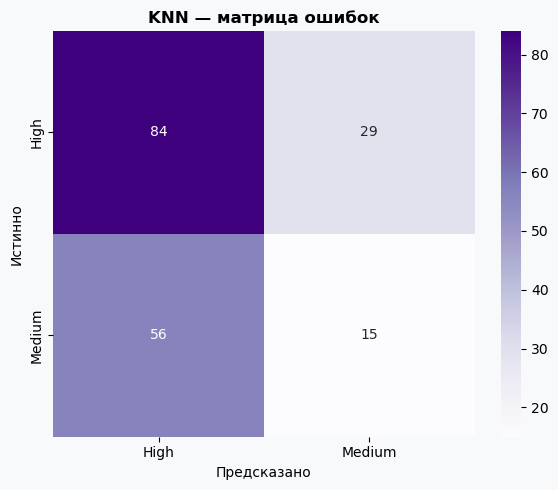

In [42]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, ax=ax)
ax.set_title('KNN — матрица ошибок', fontweight='bold')
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинно')
plt.tight_layout()
plt.show()

Средний результат. Распознаёт 84 из 113 High (74%) и 15 из 71 Medium (21%).
   Качество хуже Random Forest, но лучше логистической регрессии.
   KNN чувствителен к выбору k и метрике расстояния — при тонкой
   настройке может улучшиться.

## Сравнение методов

In [43]:
results = pd.DataFrame({
    'Модель':     ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy':   [acc_lr,  acc_rf,  acc_knn],
    'Precision':  [prec_lr, prec_rf, prec_knn],
    'Recall':     [rec_lr,  rec_rf,  rec_knn],
    'F1-Score':   [f1_lr,   f1_rf,   f1_knn]
})

print(results.to_string(index=False))

             Модель  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.614130   0.377156 0.614130  0.467318
      Random Forest  0.608696   0.576062 0.608696  0.561391
                KNN  0.538043   0.500025 0.538043  0.508464


ROC-кривая для всех трех моделей

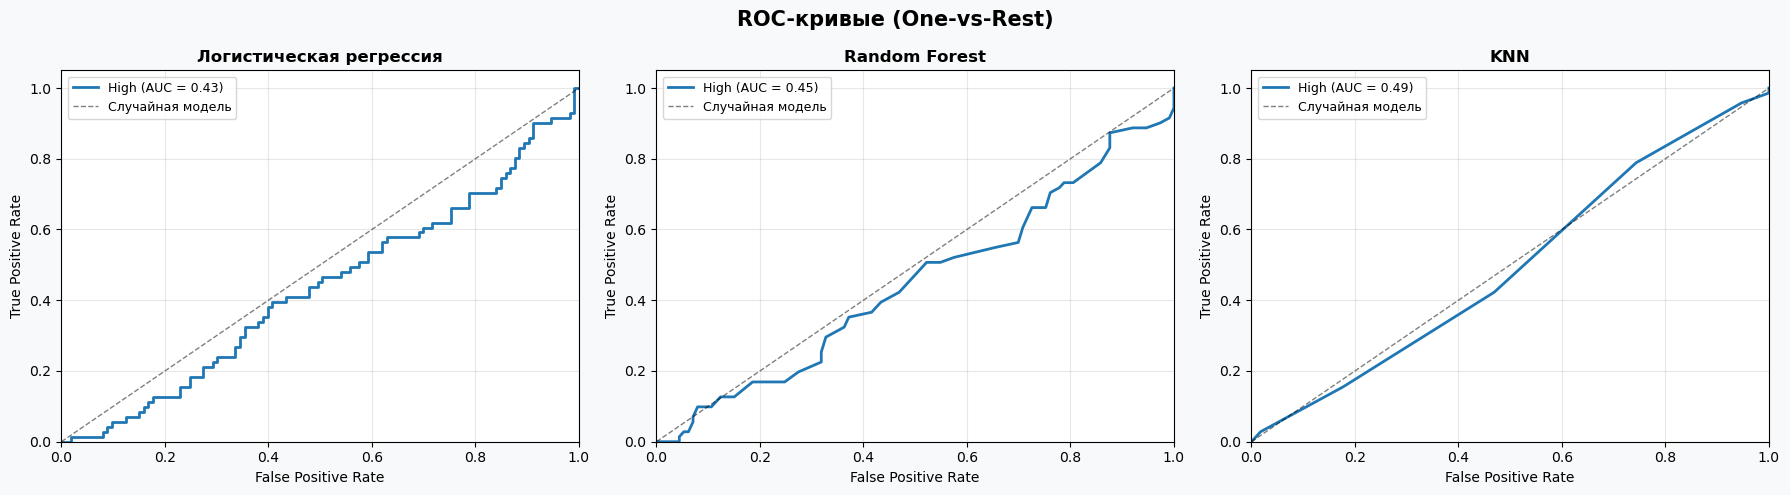

In [44]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = list(range(len(le_target.classes_)))
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC-кривые (One-vs-Rest)', fontsize=15, fontweight='bold')

models_info = [
    (model_lr,  X_test_sc, 'Логистическая регрессия', '#4361EE'),
    (model_rf,  X_test_sc, 'Random Forest',            '#06D6A0'),
    (model_knn, X_test_sc, 'KNN',                      '#F72585'),
]

for ax, (model, X_t, name, color) in zip(axes, models_info):
    y_prob = model.predict_proba(X_t)
    
    for i, cls_name in enumerate(le_target.classes_):
        if y_test_bin.shape[1] > i:
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, linewidth=2,
                    label=f'{cls_name} (AUC = {roc_auc:.2f})')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Случайная модель')
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

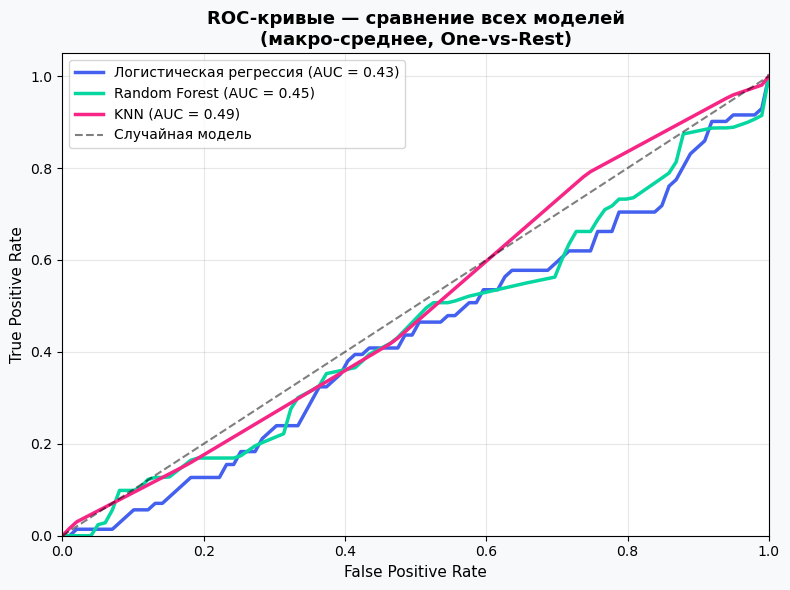

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))

for model, X_t, name, color in models_info:
    y_prob = model.predict_proba(X_t)
    
    fpr_all, tpr_all = [], []
    for i in range(y_test_bin.shape[1]):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        fpr_all.append(fpr)
        tpr_all.append(tpr)
    
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.mean([np.interp(mean_fpr, f, t) for f, t in zip(fpr_all, tpr_all)], axis=0)
    macro_auc = auc(mean_fpr, mean_tpr)
    
    ax.plot(mean_fpr, mean_tpr, color=color, linewidth=2.5,
            label=f'{name} (AUC = {macro_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Случайная модель')
ax.set_title('ROC-кривые — сравнение всех моделей\n(макро-среднее, One-vs-Rest)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

Лучший результат ожидаемо показывает Random Forest — он наиболее устойчив к шуму и лучше работает на сложных взаимодействиях признаков, что подтверждалось ещё при анализе корреляционной матрицы.

Сохраняю лучшую модель

In [46]:
import os
import joblib

os.makedirs('models', exist_ok=True)

joblib.dump(model_rf, 'C:/Users/User/OneDrive/Документы/машинка/random_forest.pkl')
joblib.dump(scaler, 'C:/Users/User/OneDrive/Документы/машинка/scaler.pkl')
joblib.dump(le_target, 'C:/Users/User/OneDrive/Документы/машинка/label_encoder.pkl')

print("Сохранил:")

Сохранил:


In [47]:
df.to_csv('student_performance_updated_1000.csv',index=False)

## Заключение

В ходе работы был проведён полный цикл анализа данных успеваемости 1000 студентов — от очистки до построения моделей машинного обучения.